<a href="https://colab.research.google.com/github/nadilHesara/langid_experiments/blob/main/LangID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sinhala-Script LangID
classify a sentence written in the Sinhala script as `sinhala`, `pali`, or `sanskrit`.

In [ ]:

%pip install -q fasttext-wheel langdetect scikit-learn pandas matplotlib joblib
%pip install -q gensim

import os, re, random, unicodedata
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED)

CORE_LABELS = ["sinhala", "pali", "sanskrit"]

OUTPUT_DIR = "/content/drive/MyDrive/SSLI/processed"


##Raw data loading

###sinhala paali parallel corpus

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/SSLI/raw_data/sinhala_paali_parallel_corpus/output.tsv"

df = pd.read_csv(path, sep="\t")
print(df.shape)
print(df.columns.tolist())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(28395, 2)
['pali_text', 'sinhala_text']


,pali_text,sinhala_text
0,එවං මෙ සුතං - එකං සමයං භගවා අන්තරා ච රාජගහං අන...,මා විසින් මෙසේ අසනලදී. (නොහොත් මගේ ඇසීම මෙලෙසය...
1,අථ ඛො භගවා අම්බලට්ඨිකායං රාජාගාරකෙ එකරත්තිවාසං...,එවිට භාග්‍යවතුන් වහන්සේ අම්බලට්ඨිකා උයනෙහි රජු...
2,අථ ඛො සම්බහුලානං භික්ඛූනං රත්තියා පච්චූසසමයං ප...,එකල රෑ පාන්දරින් මණ්ඩලමාල නම් රැස්වීම් ශාලාවෙහ...
3,අථ ඛො භගවා තෙසං භික්ඛූනං ඉමං සඞ්ඛියධම්මං විදිත...,එකල්හි භාග්‍යවතුන් වහන්සේ භික්ෂූන්ගේ මේ කථාව ද...
4,"‘‘මමං වා, භික්ඛවෙ, පරෙ අවණ්ණං භාසෙය්‍යුං, ධම්ම...","“මහණෙනි, අනුන් මාගේ හෝ නුගුණ කියද්ද, ධර්මය ගැන..."


###Pali documents(SiDiaC-v2)

In [ ]:
import os

folder = "/content/drive/.shortcut-targets-by-id/1gPCbEcE9ztxyuWFqpVtSSNpel4wklH_g/SSLI/raw_data/doc/paali"

txt_files = [f for f in os.listdir(folder) if f.endswith(".txt")]
print(f"Found {len(txt_files)} files:")
for f in txt_files:
    print(f)

Found 15 files:
අධිමාස දීපනය.txt
බුද්ධ සික්ඛා.txt
මහාවංස ටීකා.txt
සුමංගල විලාසිනි නාමා දීඝනිකාය අට්ඨකථා.txt
සාදුපත්ථපුරණී.txt
සාදුජනපපසාදිනී.txt
සමෙමාහනාසිනී.txt
මහාරූපසිද්ධි.txt
මොග්ගලලායනව්_යාකරණං.txt
අධිකරණ විභාග සංඝෝ.txt
මාහාවංසො (තුතියෝ භාගෝ).txt
ප්_රපංච සුදනීනාම මජ්ජිම නිකාය අට්ඨකථා හෙවත් මැදුම් සඟි අටුවාව.txt
ධම්මපදට්ඨ කථා - දුතියො භාගො.txt
දීපවංසෝ.txt
ජාතකට්ඨකථා.txt


In [ ]:
import re, pandas as pd

label_map = {
    "අධිමාස": "pali", "කුදුසික": "pali", "ටීකා": "pali",
    "සුමංගල": "pali", "සාදුපත්ථ": "pali", "සාදුජනප": "pali",
    "සමෙමාහන": "pali", "බුද්ධ සික්ඛා": "pali", "මහාරූපසිද්ධි": "pali",
    "ග්ගලලායන": "pali", "අධිකරණ": "pali", "මාහාවංසො": "pali",
    "ප්_රපංච": "pali", "ප්රපංච": "pali",
    "පබ්බතූපම": "pali_then_sinhala",
    "ධම්මපදට්ඨ": "pali", "දීපවංසෝ": "pali", "ජාතකට්ඨකථා": "pali",
    "කවච": "sanskrit_from_line40",
    "චරියා": "EXCLUDE_COPYRIGHT",
}

import unicodedata

def normalize(s):
    return unicodedata.normalize("NFC", s)

def find_label(filename):
    filename_norm = normalize(filename)
    for key, val in label_map.items():
        if normalize(key) in filename_norm:
            return val
    return "UNKNOWN"

rows = []
skipped = []

for fname in txt_files:
    label = find_label(fname)
    book_title = fname.replace(".txt", "")

    if label in ("EXCLUDE_COPYRIGHT", "UNKNOWN"):
        skipped.append((fname, label))
        continue

    with open(os.path.join(folder, fname), encoding="utf-8") as f:
        text = f.read()

    lines = [l.strip() for l in text.split("\n")]
    lines = [l for l in lines if len(l) > 5 and not re.fullmatch(r"[\d\.\s]+", l)]

    if label == "pali_then_sinhala":
        skipped.append((fname, "needs manual pali/sinhala split"))
        continue

    if label == "sanskrit_from_line40":
        lines = lines[39:]
        label = "sanskrit"

    for sent in lines:
        rows.append({
            "text": sent,
            "label": label,
            "source": "SiDiaC-v2",
            "subcorpus": book_title,
            "group_id": f"sidiac2_{book_title}"
        })

sidiac_df = pd.DataFrame(rows)
print(sidiac_df.shape)
print(sidiac_df["label"].value_counts())
print("\nSkipped/flagged:")
for s in skipped:
    print(s)

(2929, 5)
label
pali    2929
Name: count, dtype: int64

Skipped/flagged:


####Sanskrit documents(SiDiaC-v2)

In [ ]:
sanskrit_folder = "/content/drive/.shortcut-targets-by-id/1gPCbEcE9ztxyuWFqpVtSSNpel4wklH_g/SSLI/raw_data/doc/sasnkrit"

sanskrit_rows = []
for fname in os.listdir(sanskrit_folder):
    if not fname.endswith(".txt"):
        continue
    with open(os.path.join(sanskrit_folder, fname), encoding="utf-8") as f:
        text = f.read()
    lines = [l.strip() for l in text.split("\n")]
    lines = lines[39:]  # skip 39-lines
    lines = [l for l in lines if len(l) > 5 and not re.fullmatch(r"[\d\.\s]+", l)]
    book = fname.replace(".txt", "")
    for sent in lines:
        sanskrit_rows.append({
            "text": sent, "label": "sanskrit", "source": "SiDiaC-v2",
            "subcorpus": book, "group_id": f"sidiac2_{book}",
        })

sanskrit_df = pd.DataFrame(sanskrit_rows)
sidiac_df = pd.concat([sidiac_df, sanskrit_df], ignore_index=True)
print(sidiac_df["label"].value_counts())


label
pali        2929
sanskrit     101
Name: count, dtype: int64


###Sanskrit New Testament (SansinNT, USFX XML)
The New Testament written in **Sinhala script** but in the **Sanskrit language**.
Every verse becomes a `sanskrit` example

In [ ]:
import os
import xml.etree.ElementTree as ET

sansin_path = "/content/drive/.shortcut-targets-by-id/1gPCbEcE9ztxyuWFqpVtSSNpel4wklH_g/SSLI/raw_data/sansinNT_sanskrit/sansin_usfx.xml"

if not os.path.exists(sansin_path):
    raise FileNotFoundError(f"Can't find:\n{sansin_path}\nCheck the folder path in Drive and fix `sansin_path`.")

SKIP_TAGS = {"f", "x", "fig", "fe", "ef", "ex", "note"}

def _local(tag):
    return tag.split("}")[-1] if "}" in tag else tag

def extract_verses(book):
    """Return a list of (chapter, verse, text) for one USFX <book>."""
    out, buf = [], []
    state = {"ch": None, "v": None}

    def flush():
        if state["v"] is not None:
            t = "".join(buf).strip()
            if t:
                out.append((state["ch"], state["v"], t))

    def walk(el):
        for child in el:
            tag = _local(child.tag)
            if tag in SKIP_TAGS:
                if child.tail: buf.append(child.tail)   # keep verse text after the footnote
                continue
            if tag == "c":                               # chapter marker
                flush(); buf.clear()
                state["ch"], state["v"] = child.get("id"), None
            elif tag == "v":                             # verse start marker
                flush(); buf.clear()
                state["v"] = child.get("id")
                if child.tail: buf.append(child.tail)
            elif tag == "ve":                            # verse end marker
                flush(); buf.clear()
                state["v"] = None
                if child.tail: buf.append(child.tail)
            else:                                        # ordinary inline text
                if child.text: buf.append(child.text)
                walk(child)
                if child.tail: buf.append(child.tail)

    walk(book)
    flush()
    return out

root = ET.parse(sansin_path).getroot()

sansin_rows = []
for book in root.iter():
    if _local(book.tag) != "book":
        continue
    book_id = book.get("id") or "NT"
    for ch, v, text in extract_verses(book):
        sansin_rows.append({
            "text": text,
            "label": "sanskrit",
            "source": "SansinNT",
            "subcorpus": book_id,
            # group by CHAPTER so a whole chapter stays in one split
            "group_id": f"sansinnt_{book_id}_{ch}",
        })

sansinnt_df = pd.DataFrame(sansin_rows)
print("verses:", len(sansinnt_df),
      "| books:", sansinnt_df["subcorpus"].nunique(),
      "| chapter-groups:", sansinnt_df["group_id"].nunique())
sansinnt_df.head()


verses: 7959 | books: 27 | chapter-groups: 260


,text,label,source,subcorpus,group_id
0,ඉබ්‍රාහීමඃ සන්තානෝ දායූද් තස්‍ය සන්තානෝ යීශුඛ්...,sanskrit,SansinNT,MAT,sansinnt_MAT_1
1,ඉබ්‍රාහීමඃ පුත්‍ර ඉස්හාක් තස්‍ය පුත්‍රෝ යාකූබ්...,sanskrit,SansinNT,MAT,sansinnt_MAT_1
2,"තස්මාද් යිහූදාතස්තාමරෝ ගර්භේ පේරස්සේරහෞ ජඥාතේ,...",sanskrit,SansinNT,MAT,sansinnt_MAT_1
3,තස්‍ය පුත්‍රෝ (අ)ම්මීනාදබ් තස්‍ය පුත්‍රෝ නහශෝන...,sanskrit,SansinNT,MAT,sansinnt_MAT_1
4,"තස්මාද් රාහබෝ ගර්භේ බෝයම් ජඥේ, තස්මාද් රූතෝ ගර...",sanskrit,SansinNT,MAT,sansinnt_MAT_1


In [ ]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
sansinnt_df.to_csv(f"{OUTPUT_DIR}/sansinnt.csv", index=False)
print("saved sansinnt.csv:", len(sansinnt_df), "rows")

saved sansinnt.csv: 7959 rows


###Sanskrit classical texts (DCS → transliterated to Sinhala)
Here we add classical Sanskrit (poetry, philosophy) from the **Digital Corpus of Sanskrit** (CC BY 4.0).
DCS text is romanised (SLP1); we convert the **letters** to Sinhala script with **Aksharamukha**

In [ ]:
%pip install -q aksharamukha
import urllib.request
from aksharamukha import transliterate

BASE = "https://raw.githubusercontent.com/ambuda-org/dcs/main"
# a spread of genres (the 2 giant epics are skipped to keep the class balanced)
DCS_FILES = ["amarushatakam", "caurapancashika", "meghadutam-kale", "mukundamala",
             "rtusamharam", "hamsadutam", "kokilasandesha", "shatakatrayam",
             "kumarasambhavam", "saundaranandam", "bodhicaryavatara", "kiratarjuniyam"]
MAX_PER_FILE = 1200            # keep any single text from dominating

def _dcs_sentences(raw):
    """Rebuild sentences from a DCS file: words are the 1st tab-column,
    grouped by each '# id =' block."""
    out, cur, words = [], None, []
    for line in raw.splitlines():
        if line.startswith("# id ="):
            if cur and words: out.append((cur, " ".join(words)))
            cur, words = line.split("=", 1)[1].strip(), []
        elif line.strip():
            words.append(line.split("\t")[0])
    if cur and words: out.append((cur, " ".join(words)))
    return out

dcs_rows = []
for stem in DCS_FILES:
    try:
        raw = urllib.request.urlopen(f"{BASE}/{stem}.txt", timeout=60).read().decode("utf-8")
    except Exception as e:
        print("  skip", stem, "-", e); continue

    sents = _dcs_sentences(raw)[:MAX_PER_FILE]
    ids  = [i for i, _ in sents]
    slp1 = [s for _, s in sents]

    # SLP1 -> Sinhala, whole file at once (fast). If the line count changes,
    # fall back to one-by-one so nothing gets misaligned.
    sinh = transliterate.process("Slp1", "Sinhala", "\n".join(slp1)).split("\n")
    if len(sinh) != len(slp1):
        sinh = [transliterate.process("Slp1", "Sinhala", s) for s in slp1]

    for _id, txt in zip(ids, sinh):
        parts = _id.split(".")
        grp = ".".join(parts[:-1]) if len(parts) > 1 else _id   # group by canto/chapter
        dcs_rows.append({"text": txt, "label": "sanskrit", "source": "DCS",
                         "subcorpus": stem, "group_id": f"dcs_{grp}"})
    print(f"  {stem:18s} {len(sents):5d} sentences")

dcs_df = pd.DataFrame(dcs_rows)
print("\nDCS total:", len(dcs_df),
      "| books:", dcs_df["subcorpus"].nunique(),
      "| groups:", dcs_df["group_id"].nunique())
dcs_df.head()


  amarushatakam        106 sentences
  caurapancashika       50 sentences
  meghadutam-kale      121 sentences
  mukundamala           34 sentences
  rtusamharam          158 sentences
  hamsadutam           100 sentences
  kokilasandesha       162 sentences
  shatakatrayam        324 sentences
  kumarasambhavam      613 sentences
  saundaranandam      1063 sentences
  bodhicaryavatara     913 sentences
  kiratarjuniyam      1040 sentences

DCS total: 4684 | books: 12 | groups: 71


,text,label,source,subcorpus,group_id
0,ජ්‍යා කෘෂ්ටි බද්ධ ඛටකා මුඛ පාණි පෘෂ්ඨ ප්‍රේඞ්ඛ...,sanskrit,DCS,amarushatakam,dcs_AmrShtk
1,ක්‍ෂිප්තෝ හස්ත අවලග්නඃ ප්‍රසභම් අභිහතෝ (අ)ප්‍ය...,sanskrit,DCS,amarushatakam,dcs_AmrShtk
2,ආලෝලාම් අලක ආවලීම් විලුලිතාම් භෘ චල් කුණ්ඩලම් ...,sanskrit,DCS,amarushatakam,dcs_AmrShtk
3,අලස වලිතෛඃ ප්‍රේම ආර්ද්‍ර ආර්ද්‍රෛඃ මුහුඃ මුකු...,sanskrit,DCS,amarushatakam,dcs_AmrShtk
4,දත්තඃ අස්‍යාඃ ප්‍රණයඃ ත්වයා ඒව භවතා ච ඉයම් චිර...,sanskrit,DCS,amarushatakam,dcs_AmrShtk


In [ ]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
dcs_df.to_csv(f"{OUTPUT_DIR}/dcs.csv", index=False)
print("saved dcs.csv:", len(dcs_df), "rows")

saved dcs.csv: 4684 rows


###Reshape parallel corpus to long form

In [ ]:
pali_rows = df[["pali_text"]].rename(columns={"pali_text": "text"})
pali_rows["label"] = "pali"

sinhala_rows = df[["sinhala_text"]].rename(columns={"sinhala_text": "text"})
sinhala_rows["label"] = "sinhala"

parallel_long = pd.concat([pali_rows, sinhala_rows], ignore_index=True)
parallel_long["source"] = "pali-sinhala-parallel"
parallel_long["subcorpus"] = "parallel_corpus"
parallel_long["group_id"] = "parallel_" + parallel_long.index.astype(str)

print(parallel_long.shape)
print(parallel_long["label"].value_counts())

(56790, 5)
label
pali       28395
sinhala    28395
Name: count, dtype: int64


##SiPaKosa Sinhala dataset loading

In [ ]:
#Cap the size so this single source can't dominate the whole dataset(pali/sanskrit only have a
# few thousand sentences each)—6000 is a starting point
SIPAKOSA_MAX_SENTENCES = 6000

sipakosa_urls = [
    "https://huggingface.co/datasets/RaniduG/SiPaKosa-Sent/resolve/main/data/sinhala/train.csv",
    "https://huggingface.co/datasets/RaniduG/SiPaKosa-Sent/resolve/main/data/sinhala/validation.csv",
    "https://huggingface.co/datasets/RaniduG/SiPaKosa-Sent/resolve/main/data/sinhala/test.csv",
]

sipakosa_raw = pd.concat([pd.read_csv(u) for u in sipakosa_urls], ignore_index=True)
print("SiPaKosa raw rows:", sipakosa_raw.shape)
print(sipakosa_raw["language"].value_counts())

sipakosa_raw = sipakosa_raw[sipakosa_raw["language"] == "sinhala"]
sipakosa_raw = sipakosa_raw.dropna(subset=["text"])
sipakosa_raw = sipakosa_raw[sipakosa_raw["text"].str.len() > 5]

if len(sipakosa_raw) > SIPAKOSA_MAX_SENTENCES:
    sipakosa_raw = sipakosa_raw.sample(n=SIPAKOSA_MAX_SENTENCES, random_state=SEED)

def sipakosa_group(row):
    #group by book so a whole book stays on one side of the split (no leakage)
    book = row.get("book_name_si") or row.get("book_name_en") or row.get("book_category") or "unknown"
    return f"sipakosa_{row['source']}_{book}"

sipakosa_df = pd.DataFrame({
    "text": sipakosa_raw["text"].values,
    "label": "sinhala",
    "source": "SiPaKosa",
    "subcorpus": sipakosa_raw["book_category"].fillna("unknown").values,
    "group_id": sipakosa_raw.apply(sipakosa_group, axis=1).values,
})

print(sipakosa_df.shape)
print("groups:", sipakosa_df["group_id"].nunique())
sipakosa_df.head()


SiPaKosa raw rows: (465539, 7)
language
sinhala    465539
Name: count, dtype: int64
(6000, 5)
groups: 15


,text,label,source,subcorpus,group_id
0,විමුක්තියෙන් යුක්ත ද නොවෙයි,sinhala,SiPaKosa,tripitaka,sipakosa_Tripitaka_nan
1,මා විසින් මේ සත්වයෝ මවන ලද්දාහු ය,sinhala,SiPaKosa,tripitaka,sipakosa_Tripitaka_nan
2,සොයුරිය ත් සොයුරිය හා යළි මුණගැස්සුවේ ය,sinhala,SiPaKosa,tripitaka,sipakosa_Tripitaka_nan
3,"මුඹ වහන්සේ පිටි පස්සේ සිටි නියාව මා දුට, පාන් ...",sinhala,SiPaKosa,old-books,sipakosa_IFBC_සද්ධර්ම රත්නාවලිය
4,මුදු මොළොක් අත් පා ඇති වෙනවා,sinhala,SiPaKosa,tripitaka,sipakosa_Tripitaka_nan


##Build unified dataset(clean + dedup)

In [ ]:
def clean_text(s):
    s = str(s)
    s = re.sub(r"<[^>]+>", " ", s)      # strip markup/OCR tags like <psi>, <eos>
    s = re.sub(r"\s+", " ", s).strip()
    return s

unified = pd.concat([sidiac_df, sansinnt_df, dcs_df, parallel_long, sipakosa_df], ignore_index=True)
unified = unified.dropna(subset=["text"])
unified["text"] = unified["text"].map(clean_text)
unified = unified[unified["text"].str.len() > 0]

before = len(unified)
unified = unified.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Removed {before - len(unified)} duplicate/empty sentences")

unified["id"] = range(len(unified))
unified = unified[["id", "text", "label", "source", "subcorpus", "group_id"]]
print(unified.shape)
print(unified["label"].value_counts())
unified.head()


Removed 4145 duplicate/empty sentences
(74318, 6)
label
sinhala     32263
pali        29317
sanskrit    12738
Name: count, dtype: int64


,id,text,label,source,subcorpus,group_id
0,0,අධිමාසංදීපනි.,pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය
1,1,නමො අද්වයවාදිනො සම්මා සම්බුද්ධස්ස.,pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය
2,2,1 නමාමී බුද්ධං චතුසච්ච බුද්ධං,pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය
3,3,"නමාමි ධම්මං අධිමොක්ඛ ධම්මං,",pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය
4,4,නමාමි සංඝං හතපාප සංඝං,pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය


In [ ]:
print("Groups per label:")
print(unified.groupby("label")["group_id"].nunique())


Groups per label:
label
pali        26435
sanskrit      332
sinhala     26551
Name: group_id, dtype: int64


##Group-stratified split + save

In [ ]:
from sklearn.model_selection import GroupShuffleSplit


def group_stratified_split(data, group_col, label_col, source_col="source", seed=42, min_groups_for_group_split=3):
    splits = {"train": [], "val": [], "test": []}

    for (label, source), sub in data.groupby([label_col, source_col]):
        n_groups = sub[group_col].nunique()

        if n_groups < min_groups_for_group_split:
            from sklearn.model_selection import train_test_split
            train, temp = train_test_split(sub, test_size=0.2, random_state=seed)
            val, test = train_test_split(temp, test_size=0.5, random_state=seed)
        else:
            gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
            train_idx, temp_idx = next(gss1.split(sub, groups=sub[group_col]))
            train = sub.iloc[train_idx]
            temp = sub.iloc[temp_idx]

            gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
            val_idx, test_idx = next(gss2.split(temp, groups=temp[group_col]))
            val = temp.iloc[val_idx]
            test = temp.iloc[test_idx]

        splits["train"].append(train)
        splits["val"].append(val)
        splits["test"].append(test)

    return {k: pd.concat(v, ignore_index=True) for k, v in splits.items()}

splits = group_stratified_split(unified, group_col="group_id", label_col="label", source_col="source")

for name, part in splits.items():
    print(f"\n--- {name} ---")
    print(part.groupby(["label", "source"]).size())


--- train ---
label     source               
pali      SiDiaC-v2                 2354
          pali-sinhala-parallel    21136
sanskrit  DCS                       3633
          SansinNT                  6407
          SiDiaC-v2                   80
sinhala   SiPaKosa                  5447
          pali-sinhala-parallel    21228
dtype: int64

--- val ---
label     source               
pali      SiDiaC-v2                 158
          pali-sinhala-parallel    2642
sanskrit  DCS                       509
          SansinNT                  772
          SiDiaC-v2                  10
sinhala   SiPaKosa                  241
          pali-sinhala-parallel    2654
dtype: int64

--- test ---
label     source               
pali      SiDiaC-v2                 385
          pali-sinhala-parallel    2642
sanskrit  DCS                       542
          SansinNT                  774
          SiDiaC-v2                  11
sinhala   SiPaKosa                   39
          pali-sinhala-parall

In [ ]:
# Save the exact split so every model trains/tests on identical data (fair benchmark).
os.makedirs(OUTPUT_DIR, exist_ok=True)
unified.to_csv(f"{OUTPUT_DIR}/unified.csv", index=False)
for name, part in splits.items():
    part.to_csv(f"{OUTPUT_DIR}/{name}.csv", index=False)
    print(f"saved {name}: {len(part)} rows")

train, val, test = splits["train"], splits["val"], splits["test"]


saved train: 60285 rows
saved val: 6986 rows
saved test: 7047 rows


In [ ]:
with open('/content/drive/MyDrive/SSLI/processed/unified.csv', 'rb') as f:
    data = f.read()
try:
    data.decode('utf-8')
except UnicodeDecodeError as e:
    print(e)
    print(data[e.start-50:e.end+50])  # show bytes around the error

##Evaluation utilities(shared by every model)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

RESULTS = []  # every model appends one row here -> the benchmark table

def evaluate_model(name, y_true, y_pred, note=""):
    y_true, y_pred = list(y_true), list(y_pred)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=CORE_LABELS, average="macro", zero_division=0)
    per_class = f1_score(y_true, y_pred, labels=CORE_LABELS, average=None, zero_division=0)
    row = {"model": name, "accuracy": round(acc, 3), "macro_F1": round(macro_f1, 3)}
    for lab, f in zip(CORE_LABELS, per_class):
        row[f"F1_{lab}"] = round(float(f), 3)
    if note:
        row["note"] = note

    for i, r in enumerate(RESULTS):
        if r["model"] == name:
            RESULTS[i] = row
            break
    else:
        RESULTS.append(row)
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, labels=CORE_LABELS, zero_division=0))
    return row

def show_confusion(name, y_true, y_pred):
    labels = CORE_LABELS + (["other"] if "other" in set(y_pred) else [])
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labels],
                             columns=[f"pred_{l}" for l in labels])
    print(f"\nConfusion matrix — {name}")
    print(cm_df)
    try:
        fig, ax = plt.subplots(figsize=(4.5, 4))
        ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, cm[i, j], ha="center", va="center")
        ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(name)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("(plot skipped:", e, ")")


##Model 1 - char n-gram + Logistic Regression


=== char n-gram + LogReg(baseline) ===
              precision    recall  f1-score   support

     sinhala       1.00      1.00      1.00      2693
        pali       1.00      1.00      1.00      3027
    sanskrit       1.00      1.00      1.00      1327

    accuracy                           1.00      7047
   macro avg       1.00      1.00      1.00      7047
weighted avg       1.00      1.00      1.00      7047


Confusion matrix — char n-gram + LogReg(baseline)
               pred_sinhala  pred_pali  pred_sanskrit
true_sinhala           2693          0              0
true_pali                 9       3018              0
true_sanskrit             1          1           1325


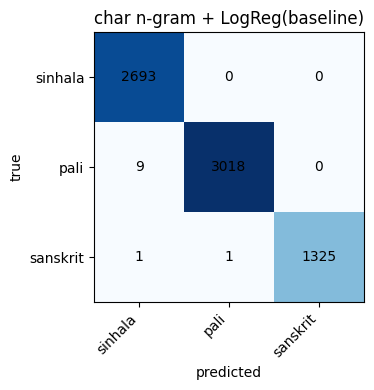

saved baseline model


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib

# character n-grams (2-4 chars): capture spelling / word-ending patterns that
# differ between the three languages even though they share the Sinhala script.
vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(2, 4), max_features=20000)
X_train = vectorizer.fit_transform(train["text"])
X_test  = vectorizer.transform(test["text"])

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, train["label"])

base_preds = clf.predict(X_test)
evaluate_model("char n-gram + LogReg(baseline)", test["label"], base_preds)
show_confusion("char n-gram + LogReg(baseline)", test["label"], base_preds)

# save for the Streamlit demo later
joblib.dump({"vectorizer": vectorizer, "clf": clf}, f"{OUTPUT_DIR}/baseline_charngram.joblib")
print("saved baseline model")


In [ ]:
# ── Cross-source sanity check (leave-one-source-out) ──
# Question: did the model learn the LANGUAGE, or just each source's "fingerprint"?
# For each source we HOLD IT OUT of training, train on everything else, then test
# ONLY on it. If a language is still recognised when its source was never seen in
# training, the model genuinely learned the language (not the source).

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

rows = []
for held_out in sorted(unified["source"].unique()):
    train = unified[unified["source"] != held_out]
    test  = unified[unified["source"] == held_out]

    # which labels in the held-out source ALSO appear in training (from other sources)?
    covered   = set(test["label"]) & set(train["label"])
    uncovered = set(test["label"]) - set(train["label"])   # label has no other source

    # only score rows whose label the model had a chance to learn elsewhere
    testable = test[test["label"].isin(covered)]
    if len(testable) == 0:
        acc = float("nan")
    else:
        vec = TfidfVectorizer(analyzer="char", ngram_range=(2, 4), max_features=20000)
        clf = LogisticRegression(max_iter=1000, class_weight="balanced")
        clf.fit(vec.fit_transform(train["text"]), train["label"])
        acc = accuracy_score(testable["label"], clf.predict(vec.transform(testable["text"])))

    rows.append({
        "held_out_source":    held_out,
        "test_rows":          len(test),
        "labels_in_source":   ", ".join(sorted(set(test["label"]))),
        "single_source_only": ", ".join(sorted(uncovered)) or "-",
        "cross_source_acc":   round(acc, 3) if acc == acc else "n/a",
    })

crosssrc_df = pd.DataFrame(rows)
crosssrc_df.to_csv(f"{OUTPUT_DIR}/cross_source_eval.csv", index=False)
crosssrc_df

,held_out_source,test_rows,labels_in_source,single_source_only,cross_source_acc
0,DCS,4684,sanskrit,-,0.992
1,SansinNT,7953,sanskrit,-,0.964
2,SiDiaC-v2,2998,"pali, sanskrit",-,0.814
3,SiPaKosa,5727,sinhala,-,0.973
4,pali-sinhala-parallel,52956,"pali, sinhala",-,0.991


##Model 2 - Word2Vec(word embeddings) + Logistic Regression


=== Word2Vec + LogReg ===
              precision    recall  f1-score   support

     sinhala       0.97      0.99      0.98      2693
        pali       0.99      0.95      0.97      3027
    sanskrit       0.94      0.97      0.95      1327

    accuracy                           0.97      7047
   macro avg       0.96      0.97      0.97      7047
weighted avg       0.97      0.97      0.97      7047


Confusion matrix — Word2Vec + LogReg
               pred_sinhala  pred_pali  pred_sanskrit
true_sinhala           2677         12              4
true_pali                69       2874             84
true_sanskrit            12         30           1285


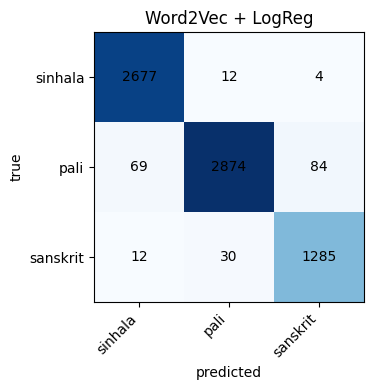

saved Word2Vec model


In [ ]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
import joblib

train, val, test = splits["train"], splits["val"], splits["test"]

def tokenize(s):
    return str(s).split()

train_tokens = [tokenize(t) for t in train["text"]]
test_tokens  = [tokenize(t) for t in test["text"]]

w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42,
)

def sentence_vector(tokens): #average of word vectors in that sentence
    vecs = [w2v.wv[w] for w in tokens if w in w2v.wv]
    if not vecs:
        return np.zeros(w2v.vector_size)   #all-unknown sentence
    return np.mean(vecs, axis=0)

X_train = np.vstack([sentence_vector(t) for t in train_tokens])
X_test  = np.vstack([sentence_vector(t) for t in test_tokens])

#classifier on top of the sentence vectors
w2v_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
w2v_clf.fit(X_train, train["label"])

w2v_preds = w2v_clf.predict(X_test)
evaluate_model("Word2Vec + LogReg", test["label"], w2v_preds)
show_confusion("Word2Vec + LogReg", test["label"], w2v_preds)

joblib.dump({"w2v": w2v, "clf": w2v_clf}, f"{OUTPUT_DIR}/word2vec_logreg.joblib")
print("saved Word2Vec model")

##Model 3 - Neural networks (character-level and word-level)

The baseline *counts* character chunks (n-grams) and weighs them. A neural network instead **learns its own patterns** while training:

1. Each character (or word) becomes a small list of numbers (an *embedding*).
2. A network layer scans the sentence and builds one summary vector for it.
3. A final layer turns that summary into 3 scores: Sinhala / Pali / Sanskrit.

We build three variants required by the project (character-level neural models, plus a word-level one for comparison):

- **3a. char-CNN** — slides small "pattern detectors" (2-5 characters wide) over the text. Like n-grams, but the patterns are learned, not fixed.
- **3b. char-BiGRU** — reads the sentence character by character, left→right **and** right→left, remembering order.
- **3c. word-BiGRU** — same idea but on whole words (we expect this to be weaker: many Pali/Sanskrit words appear only once, so the model can't learn them).

All three train on the **same train/val/test split** as the baseline, so results drop straight into the benchmark table.

In [ ]:
#Shared
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np, random

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

train, val, test = splits["train"], splits["val"], splits["test"]
label2id = {lab: i for i, lab in enumerate(CORE_LABELS)}
id2label = {i: lab for lab, i in label2id.items()}

PAD, UNK = 0, 1
chars = sorted({ch for t in train["text"] for ch in str(t)})
char2id = {ch: i + 2 for i, ch in enumerate(chars)}
print("distinct characters in train:", len(char2id))

MAX_CHARS = 200

def encode_chars(text):
    ids = [char2id.get(ch, UNK) for ch in str(text)[:MAX_CHARS]]
    return ids if ids else [UNK]

class TextDataset(Dataset):
    """Wraps a dataframe so PyTorch can read it in batches."""
    def __init__(self, df, encode_fn):
        self.x = [encode_fn(t) for t in df["text"]]
        self.y = [label2id[l] for l in df["label"]]
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.x[i], self.y[i]

def pad_batch(batch):
    """Sentences have different lengths -> pad shorter ones with 0 so they fit in one matrix."""
    xs, ys = zip(*batch)
    max_len = max(len(x) for x in xs)
    padded = torch.zeros(len(xs), max_len, dtype=torch.long)
    for i, x in enumerate(xs):
        padded[i, :len(x)] = torch.tensor(x)
    return padded, torch.tensor(ys)

counts = train["label"].value_counts()
class_weights = torch.tensor(
    [len(train) / (len(CORE_LABELS) * counts[lab]) for lab in CORE_LABELS],
    dtype=torch.float,
).to(device)
print("class weights:", {lab: round(w, 2) for lab, w in zip(CORE_LABELS, class_weights.tolist())})

Training on: cuda
distinct characters in train: 185
class weights: {'sinhala': 0.75, 'pali': 0.86, 'sanskrit': 1.99}


In [ ]:
#Shared training loop
from sklearn.metrics import f1_score as _f1

def run_epoch(model, loader, loss_fn, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    all_true, all_pred, total_loss = [], [], 0.0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(yb)
            all_true += yb.tolist()
            all_pred += logits.argmax(1).tolist()
    macro = _f1(all_true, all_pred, average="macro", zero_division=0)
    return total_loss / len(all_true), macro

def train_neural(model, name, encode_fn, epochs=15, patience=3, batch_size=64, lr=1e-3):
    """Train with early stopping: keep the weights from the epoch with best val macro-F1."""
    train_dl = DataLoader(TextDataset(train, encode_fn), batch_size=batch_size,
                          shuffle=True, collate_fn=pad_batch)
    val_dl   = DataLoader(TextDataset(val, encode_fn), batch_size=batch_size,
                          collate_fn=pad_batch)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_f1, best_state, bad_epochs = -1, None, 0
    for ep in range(1, epochs + 1):
        tr_loss, tr_f1 = run_epoch(model, train_dl, loss_fn, optimizer)
        va_loss, va_f1 = run_epoch(model, val_dl, loss_fn)
        print(f"[{name}] epoch {ep:2d}  train_loss {tr_loss:.3f}  val_macroF1 {va_f1:.3f}")
        if va_f1 > best_f1:
            best_f1, bad_epochs = va_f1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{name}] early stop (no val improvement for {patience} epochs)")
                break
    model.load_state_dict(best_state)
    return model

def predict_neural(model, df, encode_fn, batch_size=64):
    dl = DataLoader(TextDataset(df, encode_fn), batch_size=batch_size, collate_fn=pad_batch)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in dl:
            preds += model(xb.to(device)).argmax(1).tolist()
    return [id2label[p] for p in preds]

###Model 3a - Character-level CNN

[char-CNN] epoch  1  train_loss 0.041  val_macroF1 0.996
[char-CNN] epoch  2  train_loss 0.009  val_macroF1 0.997
[char-CNN] epoch  3  train_loss 0.008  val_macroF1 0.998
[char-CNN] epoch  4  train_loss 0.005  val_macroF1 0.997
[char-CNN] epoch  5  train_loss 0.007  val_macroF1 0.998
[char-CNN] epoch  6  train_loss 0.006  val_macroF1 0.994
[char-CNN] epoch  7  train_loss 0.004  val_macroF1 0.998
[char-CNN] epoch  8  train_loss 0.004  val_macroF1 0.997
[char-CNN] early stop (no val improvement for 3 epochs)

=== char-CNN ===
              precision    recall  f1-score   support

     sinhala       0.99      1.00      0.99      2693
        pali       1.00      0.99      0.99      3027
    sanskrit       1.00      1.00      1.00      1327

    accuracy                           1.00      7047
   macro avg       1.00      1.00      1.00      7047
weighted avg       1.00      1.00      1.00      7047


Confusion matrix — char-CNN
               pred_sinhala  pred_pali  pred_sanskrit
true_s

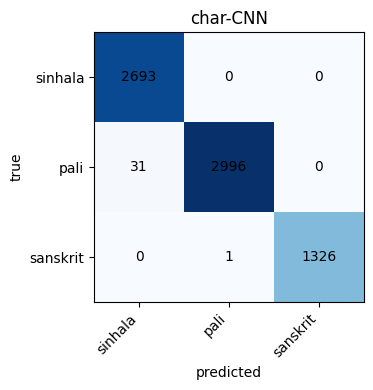

saved char-CNN


In [ ]:
class CharCNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, n_filters=128, kernel_sizes=(2, 3, 4, 5),
                 n_classes=3, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.convs = nn.ModuleList(
            [nn.Conv1d(emb_dim, n_filters, k) for k in kernel_sizes])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernel_sizes), n_classes)

    def forward(self, x):
        e = self.emb(x).transpose(1, 2)
        feats = [torch.relu(c(e)).max(dim=2).values for c in self.convs]
        return self.fc(self.dropout(torch.cat(feats, dim=1)))

char_cnn = CharCNN(vocab_size=len(char2id) + 2).to(device)
char_cnn = train_neural(char_cnn, "char-CNN", encode_chars)

cnn_preds = predict_neural(char_cnn, test, encode_chars)
evaluate_model("char-CNN", test["label"], cnn_preds)
show_confusion("char-CNN", test["label"], cnn_preds)

torch.save({"state_dict": char_cnn.state_dict(), "char2id": char2id,
            "label2id": label2id, "max_chars": MAX_CHARS},
           f"{OUTPUT_DIR}/char_cnn.pt")
print("saved char-CNN")

###Model 3b - Character-level BiGRU

[char-BiGRU] epoch  1  train_loss 0.050  val_macroF1 0.995
[char-BiGRU] epoch  2  train_loss 0.011  val_macroF1 0.996
[char-BiGRU] epoch  3  train_loss 0.007  val_macroF1 0.996
[char-BiGRU] epoch  4  train_loss 0.006  val_macroF1 0.998
[char-BiGRU] epoch  5  train_loss 0.004  val_macroF1 0.997
[char-BiGRU] epoch  6  train_loss 0.003  val_macroF1 0.996
[char-BiGRU] epoch  7  train_loss 0.002  val_macroF1 0.997
[char-BiGRU] early stop (no val improvement for 3 epochs)

=== char-BiGRU ===
              precision    recall  f1-score   support

     sinhala       0.99      1.00      1.00      2693
        pali       1.00      0.99      1.00      3027
    sanskrit       1.00      1.00      1.00      1327

    accuracy                           1.00      7047
   macro avg       1.00      1.00      1.00      7047
weighted avg       1.00      1.00      1.00      7047


Confusion matrix — char-BiGRU
               pred_sinhala  pred_pali  pred_sanskrit
true_sinhala           2693          0     

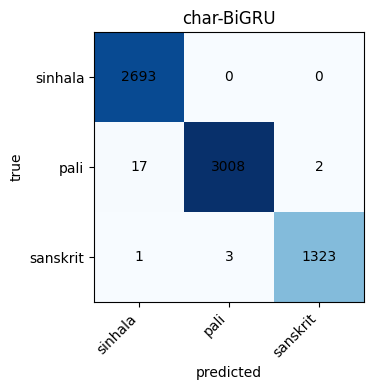

saved char-BiGRU


In [ ]:
class CharBiGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hidden=128, n_classes=3, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.gru = nn.GRU(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        e = self.emb(x)
        out, _ = self.gru(e)
        mask = (x != PAD).unsqueeze(2)
        summed = (out * mask).sum(1)
        avg = summed / mask.sum(1).clamp(min=1)
        return self.fc(self.dropout(avg))

char_gru = CharBiGRU(vocab_size=len(char2id) + 2).to(device)
char_gru = train_neural(char_gru, "char-BiGRU", encode_chars)

gru_preds = predict_neural(char_gru, test, encode_chars)
evaluate_model("char-BiGRU", test["label"], gru_preds)
show_confusion("char-BiGRU", test["label"], gru_preds)

torch.save({"state_dict": char_gru.state_dict(), "char2id": char2id,
            "label2id": label2id, "max_chars": MAX_CHARS},
           f"{OUTPUT_DIR}/char_bigru.pt")
print("saved char-BiGRU")

###Model 3c - Word-level BiGRU (comparison)

word vocab size: 152098 | words dropped as rare: 197244
[word-BiGRU] epoch  1  train_loss 0.284  val_macroF1 0.943
[word-BiGRU] epoch  2  train_loss 0.077  val_macroF1 0.957
[word-BiGRU] epoch  3  train_loss 0.038  val_macroF1 0.970
[word-BiGRU] epoch  4  train_loss 0.024  val_macroF1 0.967
[word-BiGRU] epoch  5  train_loss 0.016  val_macroF1 0.975
[word-BiGRU] epoch  6  train_loss 0.011  val_macroF1 0.975
[word-BiGRU] epoch  7  train_loss 0.009  val_macroF1 0.975
[word-BiGRU] epoch  8  train_loss 0.009  val_macroF1 0.974
[word-BiGRU] epoch  9  train_loss 0.008  val_macroF1 0.974
[word-BiGRU] epoch 10  train_loss 0.007  val_macroF1 0.977
[word-BiGRU] epoch 11  train_loss 0.007  val_macroF1 0.978
[word-BiGRU] epoch 12  train_loss 0.007  val_macroF1 0.977
[word-BiGRU] epoch 13  train_loss 0.007  val_macroF1 0.978
[word-BiGRU] epoch 14  train_loss 0.006  val_macroF1 0.978
[word-BiGRU] early stop (no val improvement for 3 epochs)

=== word-BiGRU ===
              precision    recall  f1-sc

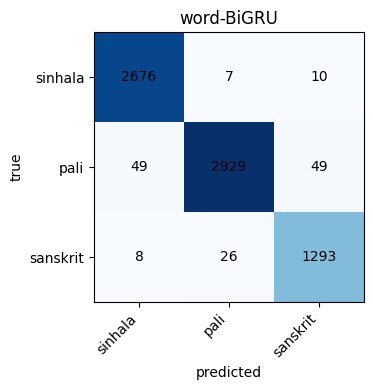

saved word-BiGRU


In [ ]:

from collections import Counter
word_counts = Counter(w for t in train["text"] for w in str(t).split())

kept_words = [w for w, c in word_counts.items() if c >= 2]
word2id = {w: i + 2 for i, w in enumerate(kept_words)}
print("word vocab size:", len(word2id),
      "| words dropped as rare:", sum(1 for c in word_counts.values() if c < 2))

MAX_WORDS = 60

def encode_words(text):
    ids = [word2id.get(w, UNK) for w in str(text).split()[:MAX_WORDS]]
    return ids if ids else [UNK]

word_gru = CharBiGRU(vocab_size=len(word2id) + 2).to(device)
word_gru = train_neural(word_gru, "word-BiGRU", encode_words)

wgru_preds = predict_neural(word_gru, test, encode_words)
evaluate_model("word-BiGRU", test["label"], wgru_preds)
show_confusion("word-BiGRU", test["label"], wgru_preds)

torch.save({"state_dict": word_gru.state_dict(), "word2id": word2id,
            "label2id": label2id, "max_words": MAX_WORDS},
           f"{OUTPUT_DIR}/word_bigru.pt")
print("saved word-BiGRU")

###Error analysis - did the neural nets fix the baseline's mistakes?

In [ ]:
import joblib

if "base_preds" not in globals():
    saved = joblib.load(f"{OUTPUT_DIR}/baseline_charngram.joblib")
    base_preds = saved["clf"].predict(saved["vectorizer"].transform(test["text"]))

base_preds = np.array(base_preds)
y_true = test["label"].to_numpy()
base_wrong = base_preds != y_true
print(f"baseline errors on test: {base_wrong.sum()} / {len(y_true)}\n")

for name, preds in [("char-CNN", cnn_preds), ("char-BiGRU", gru_preds), ("word-BiGRU", wgru_preds)]:
    preds = np.array(preds)
    fixed  = (base_wrong  & (preds == y_true)).sum()
    broken = (~base_wrong & (preds != y_true)).sum()
    print(f"{name:11s}  fixed {fixed:3d} of {base_wrong.sum()} baseline errors"
          f"  |  broke {broken:3d} previously-correct ones")

best_preds = np.array(cnn_preds)
examples = test.reset_index(drop=True)
fixed_idx = np.where(base_wrong & (best_preds == y_true))[0][:5]
still_wrong_idx = np.where(base_wrong & (best_preds != y_true))[0][:5]

print("\n-- fixed by char-CNN --")
for i in fixed_idx:
    print(f"true={y_true[i]}  baseline={base_preds[i]}  |  {examples.loc[i,'text'][:80]}")

print("\n-- still wrong (hard cases) --")
for i in still_wrong_idx:
    print(f"true={y_true[i]}  baseline={base_preds[i]}  cnn={best_preds[i]}  |  {examples.loc[i,'text'][:80]}")

baseline errors on test: 11 / 7047

char-CNN     fixed   3 of 11 baseline errors  |  broke  24 previously-correct ones
char-BiGRU   fixed   4 of 11 baseline errors  |  broke  16 previously-correct ones
word-BiGRU   fixed   5 of 11 baseline errors  |  broke 143 previously-correct ones

-- fixed by char-CNN --
true=pali  baseline=sinhala  |  අධිකරණ විභාග සංගහො
true=pali  baseline=sinhala  |  තථාහි:-
true=sanskrit  baseline=sinhala  |  තනෞමෙතුජීවෙශඃ කුක්ෂිමෙ ශුභ ලක්ෂණ්‍ය

-- still wrong (hard cases) --
true=pali  baseline=sinhala  cnn=sinhala  |  විනයන සංයමි සංයමී මුනිසො
true=pali  baseline=sinhala  cnn=sinhala  |  විනය මදෙසයි ඝාඝනායුභූතං
true=pali  baseline=sinhala  cnn=sinhala  |  අධිකරණ විභාග සංග හා
true=pali  baseline=sinhala  cnn=sinhala  |  " පේද්‍රික්
true=pali  baseline=sinhala  cnn=sinhala  |  පා කටා


##Model 4 - Multilingual transformers (fine-tuned)
Models we use (both fine-tuned the same way, same split):

- **XLM-RoBERTa base** (`xlm-roberta-base`) — the standard multilingual model; its pre-training data includes both Sinhala and Sanskrit. Primary transformer, as named in the project plan.
- **mBERT** (`bert-base-multilingual-cased`) — older 104-language model, weaker Sinhala coverage. Useful comparison point for the paper.


In [ ]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score as _f1

MAX_LEN = 128

class HFDataset(Dataset):
    """Tokenizes once up front; returns tensors the transformer expects."""
    def __init__(self, df, tokenizer):
        enc = tokenizer(list(df["text"].astype(str)), truncation=True,
                        max_length=MAX_LEN, padding=False)
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = [label2id[l] for l in df["label"]]
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return (self.input_ids[i], self.attention_mask[i], self.labels[i])

def hf_pad_batch(batch, pad_id):
    ids, masks, ys = zip(*batch)
    max_len = max(len(x) for x in ids)
    input_ids = torch.full((len(ids), max_len), pad_id, dtype=torch.long)
    attn      = torch.zeros(len(ids), max_len, dtype=torch.long)
    for i, (x, m) in enumerate(zip(ids, masks)):
        input_ids[i, :len(x)] = torch.tensor(x)
        attn[i, :len(m)] = torch.tensor(m)
    return input_ids, attn, torch.tensor(ys)

@torch.no_grad()
def hf_predict(model, tokenizer, df, batch_size=64):
    ds = HFDataset(df, tokenizer)
    dl = DataLoader(ds, batch_size=batch_size,
                    collate_fn=lambda b: hf_pad_batch(b, tokenizer.pad_token_id))
    model.eval()
    preds = []
    for input_ids, attn, _ in dl:
        logits = model(input_ids=input_ids.to(device),
                       attention_mask=attn.to(device)).logits
        preds += logits.argmax(1).tolist()
    return [id2label[p] for p in preds]

def finetune_transformer(model_name, tag, epochs=3, lr=2e-5, batch_size=16, patience=1):
    """Fine-tune any HuggingFace classification model on our split.
    Early stopping on val macro-F1 (keeps best weights). Mixed precision for T4 speed."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(CORE_LABELS),
        id2label=id2label, label2id=label2id).to(device)

    collate = lambda b: hf_pad_batch(b, tokenizer.pad_token_id)
    train_dl = DataLoader(HFDataset(train, tokenizer), batch_size=batch_size,
                          shuffle=True, collate_fn=collate)
    val_dl   = DataLoader(HFDataset(val, tokenizer), batch_size=64, collate_fn=collate)

    loss_fn = nn.CrossEntropyLoss(weight=class_weights)   #same class balancing as before
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    use_amp = (device.type == "cuda")
    scaler = torch.amp.GradScaler(enabled=use_amp)

    best_f1, best_state, bad = -1, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        total_loss, n = 0.0, 0
        for input_ids, attn, ys in train_dl:
            input_ids, attn, ys = input_ids.to(device), attn.to(device), ys.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(input_ids=input_ids, attention_mask=attn).logits
                loss = loss_fn(logits, ys)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            total_loss += loss.item() * len(ys); n += len(ys)

        #validation
        model.eval()
        vt, vp = [], []
        with torch.no_grad():
            for input_ids, attn, ys in val_dl:
                logits = model(input_ids=input_ids.to(device),
                               attention_mask=attn.to(device)).logits
                vt += ys.tolist(); vp += logits.argmax(1).tolist()
        va_f1 = _f1(vt, vp, average="macro", zero_division=0)
        print(f"[{tag}] epoch {ep}  train_loss {total_loss/n:.3f}  val_macroF1 {va_f1:.3f}")

        if va_f1 > best_f1:
            best_f1, bad = va_f1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                print(f"[{tag}] early stop"); break

    model.load_state_dict(best_state)
    return model, tokenizer

###Model 4a - XLM-RoBERTa base (fine-tuned)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[XLM-R] epoch 1  train_loss 0.037  val_macroF1 0.992
[XLM-R] epoch 2  train_loss 0.015  val_macroF1 0.997
[XLM-R] epoch 3  train_loss 0.014  val_macroF1 0.997
[XLM-R] early stop

=== XLM-R base (fine-tuned) ===
              precision    recall  f1-score   support

     sinhala       1.00      1.00      1.00      2693
        pali       1.00      1.00      1.00      3027
    sanskrit       1.00      1.00      1.00      1327

    accuracy                           1.00      7047
   macro avg       1.00      1.00      1.00      7047
weighted avg       1.00      1.00      1.00      7047


Confusion matrix — XLM-R base (fine-tuned)
               pred_sinhala  pred_pali  pred_sanskrit
true_sinhala           2692          0              1
true_pali                 8       3015              4
true_sanskrit             0          1           1326


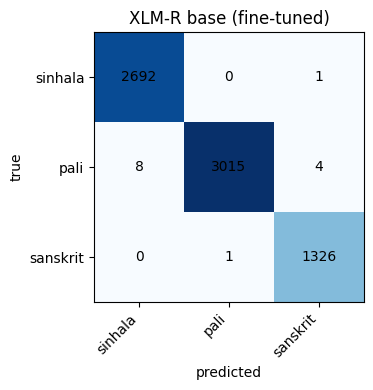

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved XLM-R model


In [ ]:
xlmr_model, xlmr_tok = finetune_transformer("xlm-roberta-base", "XLM-R")

xlmr_preds = hf_predict(xlmr_model, xlmr_tok, test)
evaluate_model("XLM-R base (fine-tuned)", test["label"], xlmr_preds)
show_confusion("XLM-R base (fine-tuned)", test["label"], xlmr_preds)

xlmr_model.save_pretrained(f"{OUTPUT_DIR}/xlmr_langid")
xlmr_tok.save_pretrained(f"{OUTPUT_DIR}/xlmr_langid")
print("saved XLM-R model")

###Model 4b - mBERT (comparison, optional)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[mBERT] epoch 1  train_loss 0.163  val_macroF1 0.959
[mBERT] epoch 2  train_loss 0.131  val_macroF1 0.964
[mBERT] epoch 3  train_loss 0.123  val_macroF1 0.968

=== mBERT (fine-tuned) ===
              precision    recall  f1-score   support

     sinhala       0.87      0.99      0.93      2693
        pali       0.99      0.90      0.94      3027
    sanskrit       0.98      0.93      0.96      1327

    accuracy                           0.94      7047
   macro avg       0.95      0.94      0.94      7047
weighted avg       0.94      0.94      0.94      7047


Confusion matrix — mBERT (fine-tuned)
               pred_sinhala  pred_pali  pred_sanskrit
true_sinhala           2656         21             16
true_pali               297       2723              7
true_sanskrit            91          0           1236


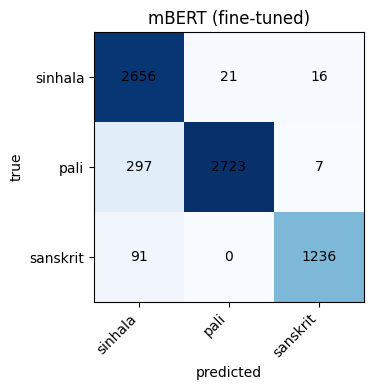

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved mBERT model


In [ ]:
mbert_model, mbert_tok = finetune_transformer("bert-base-multilingual-cased", "mBERT")

mbert_preds = hf_predict(mbert_model, mbert_tok, test)
evaluate_model("mBERT (fine-tuned)", test["label"], mbert_preds)
show_confusion("mBERT (fine-tuned)", test["label"], mbert_preds)

mbert_model.save_pretrained(f"{OUTPUT_DIR}/mbert_langid")
mbert_tok.save_pretrained(f"{OUTPUT_DIR}/mbert_langid")
print("saved mBERT model")

###Error analysis - does XLM-R fix what the baseline (and char models) missed?

In [ ]:
import joblib, numpy as np

if "base_preds" not in globals():
    saved = joblib.load(f"{OUTPUT_DIR}/baseline_charngram.joblib")
    base_preds = saved["clf"].predict(saved["vectorizer"].transform(test["text"]))

base_preds = np.array(base_preds)
y_true = test["label"].to_numpy()
base_wrong = base_preds != y_true
print(f"baseline errors on test: {base_wrong.sum()} / {len(y_true)}\n")

candidates = [("XLM-R", xlmr_preds)]
if "mbert_preds" in globals(): candidates.append(("mBERT", mbert_preds))
if "cnn_preds"   in globals(): candidates.append(("char-CNN", cnn_preds))

for name, preds in candidates:
    preds = np.array(preds)
    fixed  = (base_wrong  & (preds == y_true)).sum()
    broken = (~base_wrong & (preds != y_true)).sum()
    print(f"{name:9s}  fixed {fixed:3d} of {base_wrong.sum()} baseline errors"
          f"  |  broke {broken:3d} previously-correct ones")

# sentences NO model gets right = the genuinely hard cases -> great examples for the paper
xl = np.array(xlmr_preds)
examples = test.reset_index(drop=True)
hard_idx = np.where(base_wrong & (xl != y_true))[0][:8]
print("\n-- hard cases (baseline AND XLM-R both wrong) --")
for i in hard_idx:
    print(f"true={y_true[i]}  baseline={base_preds[i]}  xlmr={xl[i]}  |  {examples.loc[i,'text'][:80]}")

baseline errors on test: 11 / 7047

XLM-R      fixed   6 of 11 baseline errors  |  broke   9 previously-correct ones
mBERT      fixed   1 of 11 baseline errors  |  broke 422 previously-correct ones
char-CNN   fixed   3 of 11 baseline errors  |  broke  24 previously-correct ones

-- hard cases (baseline AND XLM-R both wrong) --
true=pali  baseline=sinhala  xlmr=sanskrit  |  විනය මදෙසයි ඝාඝනායුභූතං
true=pali  baseline=sinhala  xlmr=sinhala  |  අධිකරණ විභාග සංග හා
true=pali  baseline=sinhala  xlmr=sinhala  |  " පේද්‍රික්
true=pali  baseline=sinhala  xlmr=sinhala  |  “ජේම්ස් කැමල් " නාම
true=sanskrit  baseline=pali  xlmr=pali  |  අඟාරකෘසිරොදෙද්දො මුඛං


##Short fragmenting the test set - first k words

In [ ]:
# test = splits["test"]   #restore the real test split

# import joblib, numpy as np

# #reload both trained models
# base = joblib.load(f"{OUTPUT_DIR}/baseline_charngram.joblib")
# w2vm = joblib.load(f"{OUTPUT_DIR}/word2vec_logreg.joblib")

# def first_k_words(s, k):
#     return " ".join(str(s).split()[:k])

# def w2v_vec(tokens, model):
#     vecs = [model.wv[w] for w in tokens if w in model.wv]
#     return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

# for k in [1, 3, 5]:       #sentences cut to k words or fewer
#     short = test["text"].map(lambda s: first_k_words(s, k))
#     p1 = base["clf"].predict(base["vectorizer"].transform(short))
#     evaluate_model(f"char n-gram @<={k} words", test["label"], p1)
#     Xs = np.vstack([w2v_vec(str(s).split(), w2vm["w2v"]) for s in short])
#     p2 = w2vm["clf"].predict(Xs)
#     evaluate_model(f"Word2Vec @<={k} words", test["label"], p2)

##Short fragmenting - Random k words

In [ ]:
import joblib, numpy as np
import random

base = joblib.load(f"{OUTPUT_DIR}/baseline_charngram.joblib")
w2vm = joblib.load(f"{OUTPUT_DIR}/word2vec_logreg.joblib")

rng = random.Random(42)

def random_k_words(s, k):
    words = str(s).split()
    if len(words) <= k:
        return " ".join(words)                #already short:use whole thing
    start = rng.randint(0, len(words) - k)     #random start so the window fits
    return " ".join(words[start:start + k])

def w2v_vec(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

for k in [1, 3, 5]:
    short = test["text"].map(lambda s: random_k_words(s, k))
    p1 = base["clf"].predict(base["vectorizer"].transform(short))
    evaluate_model(f"char n-gram @<={k} words(random)", test["label"], p1)
    Xs = np.vstack([w2v_vec(str(s).split(), w2vm["w2v"]) for s in short])
    p2 = w2vm["clf"].predict(Xs)
    evaluate_model(f"Word2Vec @<={k} words(random)", test["label"], p2)


=== char n-gram @<=1 words(random) ===
              precision    recall  f1-score   support

     sinhala       0.62      0.96      0.75      2693
        pali       0.90      0.69      0.78      3027
    sanskrit       0.89      0.35      0.50      1327

    accuracy                           0.73      7047
   macro avg       0.80      0.67      0.68      7047
weighted avg       0.79      0.73      0.72      7047


=== Word2Vec @<=1 words(random) ===
              precision    recall  f1-score   support

     sinhala       0.60      0.79      0.68      2693
        pali       0.84      0.59      0.69      3027
    sanskrit       0.50      0.53      0.51      1327

    accuracy                           0.65      7047
   macro avg       0.65      0.63      0.63      7047
weighted avg       0.68      0.65      0.65      7047


=== char n-gram @<=3 words(random) ===
              precision    recall  f1-score   support

     sinhala       0.92      1.00      0.96      2693
        pali

##Existing-tool baselines (the comparison)

These are ready-made LangID tools. They were built assuming *Sinhala script = Sinhala language*, so they have **no Pali or Sanskrit labels**. Anything they don't map to Sinhala (`si`) we count as `other`. Expect them to score near-zero on Pali and Sanskrit — that gap is the whole point of your benchmark.

In [ ]:
# def to_core_label(code):
#     # existing tools only know 'si' among our three; everything else = other
#     return {"si": "sinhala"}.get(code, "other")

# # ---- fastText lid.176 ----
# try:
#     import fasttext, urllib.request
#     MODEL_PATH = "lid.176.ftz"
#     if not os.path.exists(MODEL_PATH):
#         urllib.request.urlretrieve(
#             "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz",
#             MODEL_PATH)
#     ft = fasttext.load_model(MODEL_PATH)

#     def ft_predict(text):
#         text = text.replace("\n", " ").strip()
#         if not text:
#             return "other"
#         code = ft.predict(text)[0][0].replace("__label__", "")
#         return to_core_label(code)

#     ft_preds = [ft_predict(t) for t in test["text"]]
#     evaluate_model("fastText lid.176 (existing)", test["label"], ft_preds,
#                    note="off-the-shelf; no Pali/Sanskrit labels")
#     show_confusion("fastText lid.176 (existing)", test["label"], ft_preds)
# except Exception as e:
#     print("fastText step skipped:", e)


In [ ]:
# # ---- langdetect ----
# try:
#     from langdetect import detect, DetectorFactory
#     DetectorFactory.seed = 0

#     def ld_predict(text):
#         text = text.strip()
#         if not text:
#             return "other"
#         try:
#             return to_core_label(detect(text))
#         except Exception:
#             return "other"

#     ld_preds = [ld_predict(t) for t in test["text"]]
#     evaluate_model("langdetect (existing)", test["label"], ld_preds,
#                    note="off-the-shelf; no Pali/Sanskrit labels")
#     show_confusion("langdetect (existing)", test["label"], ld_preds)
# except Exception as e:
#     print("langdetect step skipped:", e)


## 7. Results table (all models side by side)

How to read this for Monday:
- **accuracy** can look high for the existing tools too — but only because Sinhala dominates the data.
- Look at **F1_pali** and **F1_sanskrit**: the existing tools sit near **0**, while your char n-gram model is high.
- **macro_F1** averages the three languages equally, so it exposes the gap. That single number is your headline.

In [ ]:
results_df = (pd.DataFrame(RESULTS)
              .sort_values("macro_F1", ascending=False)
              .reset_index(drop=True))
results_df.to_csv(f"{OUTPUT_DIR}/benchmark_results.csv", index=False)
results_df


,model,accuracy,macro_F1,F1_sinhala,F1_pali,F1_sanskrit
0,char n-gram + LogReg(baseline),0.998,0.999,0.998,0.998,0.999
1,char-BiGRU,0.997,0.997,0.997,0.996,0.998
2,char-CNN,0.995,0.996,0.994,0.995,1.000
3,char n-gram @<=5 words(random),0.989,0.987,0.989,0.994,0.978
4,word-BiGRU,0.979,0.977,0.986,0.978,0.965
5,Word2Vec + LogReg,0.970,0.967,0.982,0.967,0.952
6,char n-gram @<=3 words(random),0.956,0.945,0.956,0.979,0.900
7,Word2Vec @<=5 words(random),0.922,0.911,0.955,0.923,0.854
8,Word2Vec @<=3 words(random),0.867,0.852,0.905,0.879,0.772
9,char n-gram @<=1 words(random),0.731,0.679,0.751,0.784,0.504


## 8. Next iterations (agile — add models here)

Each week, add ONE stronger model on the *same* split and let it drop into the table.

**Template** — train your model, predict on `test`, then:
```python
# my_preds = my_model.predict(test["text"])
# evaluate_model("char-CNN", test["label"], my_preds)
# show_confusion("char-CNN", test["label"], my_preds)
```

Suggested order:
1. ✅ char n-gram + LogReg (done)
2. Character-level neural net (CNN or GRU over characters)
3. Multilingual transformer (fine-tune XLM-RoBERTa) — needs a GPU

`val.csv` is for tuning hyperparameters; only touch `test.csv` for your final reported numbers.